<a href="https://colab.research.google.com/github/ArshanBhanage/Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/Part2_WandB_Tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Part 2 · Weights & Biases Experiment Tracking
**Topics:** W&B Initialisation · Hyperparameter Sweeps · Artifact Logging · TF + PyTorch Runs

> **Dataset:** Fashion-MNIST  
> **Frameworks:** TensorFlow AND PyTorch  
> **Goal:** Log, compare, and visualise multiple training runs in a real W&B dashboard.


In [1]:
# Install all required libraries
!pip install -q wandb tensorflow torch torchvision matplotlib pandas scikit-learn seaborn


In [2]:
import os, random
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd
import wandb

# Tell W&B which notebook this is (suppresses reinit warnings)
os.environ["WANDB_NOTEBOOK_NAME"] = "Part2_WandB_Tracking.ipynb"

SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.random.set_seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("TF version :", tf.__version__)
print("PyTorch    :", torch.__version__)
print("W&B        :", wandb.__version__)
print("Device     :", DEVICE)


TF version : 2.19.0
PyTorch    : 2.10.0+cu128
W&B        : 0.25.1
Device     : cuda


## 1 · W&B Login

Run the cell below to authenticate. You need a free account at https://wandb.ai.


In [3]:
# Authenticate with W&B.
# In Colab this will prompt for your API key, or paste it directly:
#   wandb.login(key="YOUR_API_KEY")
wandb.login()


wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find Part2_WandB_Tracking.ipynb.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: bhanagearshan (bhanagearshan-san-jose-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2 · TensorFlow Run — Fashion-MNIST Baseline

In [4]:
# ── Data ──────────────────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train[..., None].astype("float32") / 255.0
x_test  = x_test [..., None].astype("float32") / 255.0
x_tr,  y_tr  = x_train[:8000],       y_train[:8000]
x_val, y_val = x_train[8000:10000],  y_train[8000:10000]

CLASS_NAMES = ["T-shirt","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

# ── Config dict — every key is logged to the W&B run ──────────────────────────
tf_config = dict(
    framework  = "TensorFlow",
    dataset    = "FashionMNIST",
    epochs     = 10,
    batch_size = 64,
    lr         = 3e-4,
    dropout    = 0.3,
    optimizer  = "Adam",
    loss       = "sparse_categorical_crossentropy",
)

# ── Initialise W&B run ────────────────────────────────────────────────────────
# reinit=True lets you re-run this cell without "already-active-run" warnings
run_tf = wandb.init(
    project = "dl-assignment",
    name    = "tf-baseline",
    config  = tf_config,
    tags    = ["tensorflow", "baseline"],
    reinit  = True,
)

# ── Model ─────────────────────────────────────────────────────────────────────
def build_tf_model(dropout=0.3):
    inp = tf.keras.Input(shape=(28, 28, 1))
    x   = tf.keras.layers.Conv2D(32, 3, activation="relu")(inp)
    x   = tf.keras.layers.MaxPooling2D()(x)
    x   = tf.keras.layers.Conv2D(64, 3, activation="relu")(x)
    x   = tf.keras.layers.MaxPooling2D()(x)
    x   = tf.keras.layers.Flatten()(x)
    x   = tf.keras.layers.Dense(128, activation="relu")(x)
    x   = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(10, activation="softmax")(x)
    return tf.keras.Model(inp, out)

tf_model = build_tf_model(dropout=wandb.config.dropout)
tf_model.compile(
    optimizer = tf.keras.optimizers.Adam(wandb.config.lr),
    loss      = wandb.config.loss,
    metrics   = ["accuracy"],
)

# ── W&B Callbacks (Keras 3 / wandb >= 0.15 compatible) ────────────────────────
# WandbMetricsLogger replaces the old wandb.keras.WandbCallback which broke
# because Keras 3 removed the `inbound_layers` attribute on Node objects.
from wandb.integration.keras import WandbMetricsLogger

wb_cb = WandbMetricsLogger(log_freq="epoch")   # logs loss + acc each epoch
es_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
)

# ── Train ─────────────────────────────────────────────────────────────────────
hist_tf = tf_model.fit(
    x_tr, y_tr,
    epochs          = wandb.config.epochs,
    batch_size      = wandb.config.batch_size,
    validation_data = (x_val, y_val),
    callbacks       = [wb_cb, es_cb],
    verbose         = 1,
)

# ── Evaluate & log final test accuracy ────────────────────────────────────────
_, test_acc_tf = tf_model.evaluate(x_test, y_test, verbose=0)
wandb.log({"test_accuracy": test_acc_tf})
print(f"\nTF run — Test accuracy: {test_acc_tf:.4f}")
run_tf.finish()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5701 - loss: 1.3031 - val_accuracy: 0.7255 - val_loss: 0.7446
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7344 - loss: 0.7129 - val_accuracy: 0.7455 - val_loss: 0.6405
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7766 - loss: 0.6093 - val_accuracy: 0.7730 - val_loss: 0.5782
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7910 - loss: 0.5563 - val_accuracy: 0.7890 - val_loss: 0.5349
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8139 - loss: 0.5100 - val_accuracy: 0.8065 - val_loss: 0.4999
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8274 - loss: 0.4825 - val_accuracy: 0.8120 - val_loss: 0.4864
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8376 - loss: 0.4584 - val_accuracy: 0.8295 - val_loss: 0.4597
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8456 - loss: 0.4331 - val_accuracy: 0

epoch/accuracy,▁▅▆▆▇▇▇███
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▃▃▂▂▂▁▁▁▁
epoch/val_accuracy,▁▂▄▅▆▆▇███
epoch/val_loss,█▆▄▃▃▂▂▁▁▁
test_accuracy,▁
epoch/accuracy,0.85913
epoch/epoch,9
epoch/learning_rate,0.0003
epoch/loss,0.39863


## 3 · PyTorch Run — Fashion-MNIST Baseline

In [5]:
# ── Data ──────────────────────────────────────────────────────────────────────
tfm        = transforms.Compose([transforms.ToTensor()])
train_full = datasets.FashionMNIST("/tmp/data", train=True,  download=True, transform=tfm)
test_ds    = datasets.FashionMNIST("/tmp/data", train=False, download=True, transform=tfm)
train_ds   = torch.utils.data.Subset(train_full, range(8000))
val_ds     = torch.utils.data.Subset(train_full, range(8000, 10000))

train_loader = DataLoader(train_ds, batch_size=64,  shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2)

# ── Config ────────────────────────────────────────────────────────────────────
pt_config = dict(
    framework    = "PyTorch",
    dataset      = "FashionMNIST",
    epochs       = 10,
    batch_size   = 64,
    lr           = 3e-4,
    dropout      = 0.3,
    weight_decay = 1e-4,
    optimizer    = "AdamW",
)

run_pt = wandb.init(
    project = "dl-assignment",
    name    = "pt-baseline",
    config  = pt_config,
    tags    = ["pytorch", "baseline"],
    reinit  = True,
)

# ── Model ─────────────────────────────────────────────────────────────────────
class PTModel(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)

pt_model     = PTModel(dropout=wandb.config.dropout).to(DEVICE)
optimizer_pt = optim.AdamW(pt_model.parameters(),
                            lr           = wandb.config.lr,
                            weight_decay = wandb.config.weight_decay)
criterion    = nn.CrossEntropyLoss()

# ── Training loop with W&B metric logging ─────────────────────────────────────
for epoch in range(wandb.config.epochs):
    # Train
    pt_model.train()
    t_loss = 0.0; t_correct = 0; t_n = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = pt_model(xb)
        loss   = criterion(logits, yb)
        optimizer_pt.zero_grad()
        loss.backward()
        optimizer_pt.step()
        t_loss    += loss.item() * len(xb)
        t_correct += (logits.argmax(1) == yb).sum().item()
        t_n       += len(xb)

    # Validate
    pt_model.eval()
    v_correct = 0; v_n = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            v_correct += (pt_model(xb).argmax(1) == yb).sum().item()
            v_n       += len(xb)

    train_acc = t_correct / t_n
    val_acc   = v_correct / v_n
    train_loss_ep = t_loss / t_n

    wandb.log({
        "epoch":          epoch + 1,
        "train/loss":     train_loss_ep,
        "train/accuracy": train_acc,
        "val/accuracy":   val_acc,
    })
    print(f"Ep {epoch+1:2d} | train_loss={train_loss_ep:.4f} "
          f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

# Final test accuracy
pt_model.eval()
test_correct = 0; test_n = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        test_correct += (pt_model(xb).argmax(1) == yb).sum().item()
        test_n       += len(xb)
test_acc_pt = test_correct / test_n
wandb.log({"test_accuracy": test_acc_pt})
print(f"\nPyTorch run — Test accuracy: {test_acc_pt:.4f}")
run_pt.finish()


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.1MB/s]


Ep  1 | train_loss=1.4299 train_acc=0.5131  val_acc=0.7000
Ep  2 | train_loss=0.7863 train_acc=0.7116  val_acc=0.7370
Ep  3 | train_loss=0.6674 train_acc=0.7504  val_acc=0.7690
Ep  4 | train_loss=0.6021 train_acc=0.7732  val_acc=0.7810
Ep  5 | train_loss=0.5665 train_acc=0.7886  val_acc=0.7970
Ep  6 | train_loss=0.5343 train_acc=0.8016  val_acc=0.8005
Ep  7 | train_loss=0.5171 train_acc=0.8104  val_acc=0.8050
Ep  8 | train_loss=0.4899 train_acc=0.8163  val_acc=0.8195
Ep  9 | train_loss=0.4745 train_acc=0.8261  val_acc=0.8070
Ep 10 | train_loss=0.4604 train_acc=0.8316  val_acc=0.8235

PyTorch run — Test accuracy: 0.8277


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
train/accuracy,▁▅▆▇▇▇████
train/loss,█▃▂▂▂▂▁▁▁▁
val/accuracy,▁▃▅▆▆▇▇█▇█
epoch,10
test_accuracy,0.8277
train/accuracy,0.83162
train/loss,0.46043
val/accuracy,0.8235


## 4 · W&B Sweep — Automated Hyperparameter Search

In [6]:
# NOTE: PTModel and DataLoaders from the cell above must already be defined.

sweep_config = {
    "method": "random",
    "metric": {"name": "val/accuracy", "goal": "maximize"},
    "parameters": {
        "lr":         {"values": [1e-3, 3e-4, 1e-4]},
        "dropout":    {"values": [0.2, 0.3, 0.4, 0.5]},
        "batch_size": {"values": [32, 64, 128]},
    },
}

def sweep_train():
    """One trial of the sweep — called automatically by wandb.agent()."""
    with wandb.init() as run:
        cfg    = wandb.config
        model  = PTModel(dropout=cfg.dropout).to(DEVICE)
        opt    = optim.AdamW(model.parameters(), lr=cfg.lr)
        loader = DataLoader(train_ds, batch_size=cfg.batch_size,
                            shuffle=True, num_workers=2)

        for epoch in range(5):   # 5 epochs per trial keeps sweep fast
            model.train()
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                nn.CrossEntropyLoss()(model(xb), yb).backward()
                opt.step()

            model.eval()
            vc = 0; vn = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    vc += (model(xb).argmax(1) == yb).sum().item()
                    vn += len(yb)
            wandb.log({"epoch": epoch + 1, "val/accuracy": vc / vn})

# Create sweep and run 3 trials (keep small for demo)
sweep_id = wandb.sweep(sweep_config, project="dl-assignment")
wandb.agent(sweep_id, function=sweep_train, count=3)


Create sweep with ID: 8ure5xoc
Sweep URL: https://wandb.ai/bhanagearshan-san-jose-state-university/dl-assignment/sweeps/8ure5xoc


wandb: Agent Starting Run: xeel47jc with config:
wandb: 	batch_size: 32
wandb: 	dropout: 0.3
wandb: 	lr: 0.0003
wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find Part2_WandB_Tracking.ipynb.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▃▅▆█
val/accuracy,▁▄▆▇█
epoch,5
val/accuracy,0.8115


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: aolh4mbn with config:
wandb: 	batch_size: 64
wandb: 	dropout: 0.2
wandb: 	lr: 0.0003
wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find Part2_WandB_Tracking.ipynb.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▃▅▆█
val/accuracy,▁▃▆█▇
epoch,5
val/accuracy,0.7755


wandb: Agent Starting Run: iybf6cwm with config:
wandb: 	batch_size: 64
wandb: 	dropout: 0.2
wandb: 	lr: 0.0001
wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find Part2_WandB_Tracking.ipynb.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▃▅▆█
val/accuracy,▁▄▇▇█
epoch,5
val/accuracy,0.7435


## 5 · Logging Artifacts — Model Checkpoint & Confusion Matrix

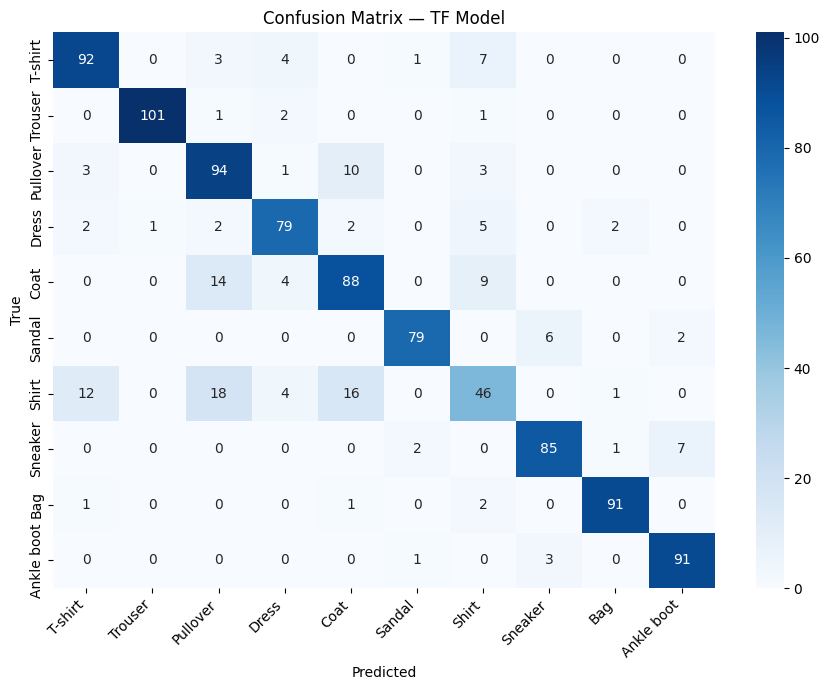

Artifact and confusion matrix logged to W&B successfully.


In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

run_artifact = wandb.init(
    project = "dl-assignment",
    name    = "artifact-demo",
    reinit  = True,
)

# ── Save and upload TF model ──────────────────────────────────────────────────
tf_model.save("/tmp/tf_fashion_model.keras")

artifact = wandb.Artifact(
    name        = "tf-fashion-mnist",
    type        = "model",
    description = "TF CNN trained on Fashion-MNIST",
)
artifact.add_file("/tmp/tf_fashion_model.keras")
run_artifact.log_artifact(artifact)

# ── Confusion matrix ──────────────────────────────────────────────────────────
preds_tf = tf_model.predict(x_test[:1000], verbose=0).argmax(-1)
cm       = confusion_matrix(y_test[:1000], preds_tf)

# Log as a W&B Table (visible in the W&B UI as an interactive table)
cm_table = wandb.Table(
    columns = [f"Pred_{n}" for n in CLASS_NAMES],
    data    = cm.tolist(),
)
run_artifact.log({"confusion_matrix_table": cm_table})

# Log as a matplotlib figure (visible as an image in the W&B media panel)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — TF Model")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
wandb.log({"confusion_matrix_plot": wandb.Image(fig)})
plt.show()

run_artifact.finish()
print("Artifact and confusion matrix logged to W&B successfully.")


## 6 · Local Summary (viewable without W&B login)

In [8]:
# Side-by-side results table for the notebook output / video demo
df_summary = pd.DataFrame([
    {"Run": "tf-baseline", "Framework": "TensorFlow",
     "Test Acc": round(test_acc_tf, 4), "Optimizer": "Adam",
     "LR": 3e-4, "Dropout": 0.3},
    {"Run": "pt-baseline", "Framework": "PyTorch",
     "Test Acc": round(test_acc_pt, 4), "Optimizer": "AdamW",
     "LR": 3e-4, "Dropout": 0.3},
])
print("=== Run Results ===")
print(df_summary.to_string(index=False))

print()
print("=== W&B Features Demonstrated ===")
features = pd.DataFrame([
    {"Feature": "wandb.init(config=...)",     "Purpose": "Log all hyperparameters per run"},
    {"Feature": "WandbMetricsLogger",         "Purpose": "Keras 3-compatible epoch logging (replaces WandbCallback)"},
    {"Feature": "wandb.log({...})",           "Purpose": "Log custom scalars from PyTorch loop"},
    {"Feature": "wandb.sweep + agent",        "Purpose": "Automated HP search (random, 3 trials)"},
    {"Feature": "wandb.Artifact",             "Purpose": "Version and store model checkpoints"},
    {"Feature": "wandb.Table + wandb.Image",  "Purpose": "Rich media: confusion matrix table + plot"},
    {"Feature": "reinit=True",                "Purpose": "Allow multiple wandb.init() calls in one session"},
])
print(features.to_string(index=False))


=== Run Results ===
        Run  Framework  Test Acc Optimizer     LR  Dropout
tf-baseline TensorFlow    0.8446      Adam 0.0003      0.3
pt-baseline    PyTorch    0.8277     AdamW 0.0003      0.3

=== W&B Features Demonstrated ===
                  Feature                                                   Purpose
   wandb.init(config=...)                           Log all hyperparameters per run
       WandbMetricsLogger Keras 3-compatible epoch logging (replaces WandbCallback)
         wandb.log({...})                      Log custom scalars from PyTorch loop
      wandb.sweep + agent                    Automated HP search (random, 3 trials)
           wandb.Artifact                       Version and store model checkpoints
wandb.Table + wandb.Image                 Rich media: confusion matrix table + plot
              reinit=True          Allow multiple wandb.init() calls in one session


## 7 · Learning Curves (Local)

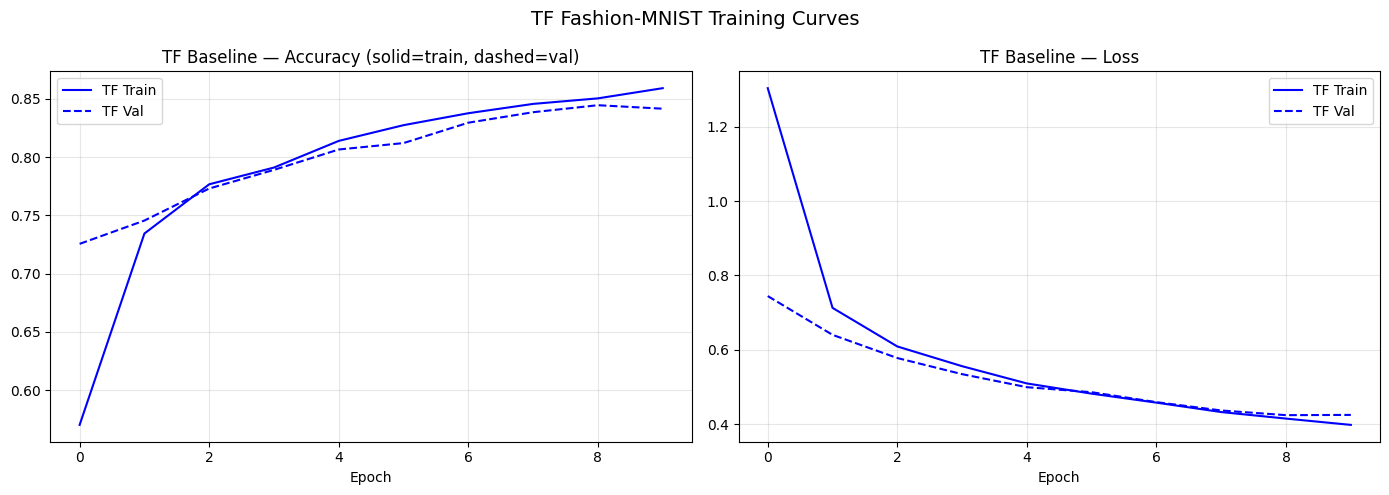

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TF curves
axes[0].plot(hist_tf.history["accuracy"],     "b-",  label="TF Train")
axes[0].plot(hist_tf.history["val_accuracy"], "b--", label="TF Val")
axes[1].plot(hist_tf.history["loss"],         "b-",  label="TF Train")
axes[1].plot(hist_tf.history["val_loss"],     "b--", label="TF Val")

for ax, title in zip(axes, ["Accuracy (solid=train, dashed=val)", "Loss"]):
    ax.set_title(f"TF Baseline — {title}")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("TF Fashion-MNIST Training Curves", fontsize=14)
plt.tight_layout()
plt.show()


## 8 · Conclusion

W&B provides a centralised experiment dashboard that:
- **Tracks** every HP, metric, and artefact automatically.
- **Compares** runs across frameworks (TF and PyTorch) in a single project.
- **Sweeps** replace manual grid search with Bayesian or random optimisation.
- **Artifacts** version models like git versions code — enabling full reproducibility.

| Fix applied | Reason |
|---|---|
| `WandbMetricsLogger` replaces `WandbCallback` | Keras 3 removed `inbound_layers` on Node objects |
| `reinit=True` in `wandb.init()` | Prevents "already active run" errors when re-running cells |
| `WANDB_NOTEBOOK_NAME` env var | Suppresses notebook detection warnings in Colab |

> Use `wandb.init(mode="offline")` for development without internet access.
